### Подготовка окружения

Добавляем путь к папке code для получения доступа к классам и функциям thinkdsp.

In [1]:
from pathlib import Path
import sys

current_path = Path.cwd()
code_path = current_path.parent / 'code'
sys.path.append(str(code_path))

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from thinkdsp import decorate, read_wave, Wave

In [3]:
def serial_corr(wave, lag=1):
    n = len(wave)
    y1 = wave.ys[lag:]
    y2 = wave.ys[:n-lag]
    corr_mat = np.corrcoef(y1, y2)
    return corr_mat[0, 1]

def autocorr(wave):
    lags = np.arange(len(wave.ys)//2)
    corrs = [serial_corr(wave, lag) for lag in lags]
    return lags, corrs

def autocorr_np(segment):
    corrs = np.correlate(segment.ys, segment.ys, mode='same')
    N = len(corrs)
    lengths = range(N, N//2, -1)
    half = corrs[N//2:].copy()
    half /= lengths
    half /= half[0]
    return half

## Упражнение 5.1

В Jupyter-тетрадке к этой главе (chap05.ipynb) есть интерактивный инструмент для вычисления автокорреляции при разных задержках. Используем этот подход для оценки высоты тона (pitch) вокального чирпа в несколько разных моментов времени.

In [4]:
wave = read_wave('../code/28042__bcjordan__voicedownbew.wav')
wave.normalize()
wave.make_audio()

Возьмём короткие сегменты (0.01 с) в разные моменты времени и для каждого найдём период сигнала через автокорреляцию.

In [5]:
def estimate_pitch(segment, low=70, high=150):
    lags, corrs = autocorr(segment)
    lag = np.array(corrs[low:high]).argmax() + low
    period = lag / segment.framerate
    frequency = 1 / period
    return frequency

start_times = [0.1, 0.2, 0.3, 0.5, 0.8, 1.0]
duration = 0.01

print("Начальное время (с) | Частота (Гц)")
print("-" * 35)
for start in start_times:
    segment = wave.segment(start=start, duration=duration)
    freq = estimate_pitch(segment)
    print(f"{start:^19.1f} | {freq:.1f}")

Начальное время (с) | Частота (Гц)
-----------------------------------
        0.1         | 484.6
        0.2         | 436.6
        0.3         | 404.6
        0.5         | 364.5
        0.8         | 336.6
        1.0         | 329.1


Частота основного тона понижается с течением времени, что соответствует нисходящему чирпу. Автокорреляционный метод даёт более точную оценку частоты, чем спектральный анализ, особенно для коротких окон.

Для примера посмотрим на автокорреляцию сегмента, начинающегося в 0.2 с.

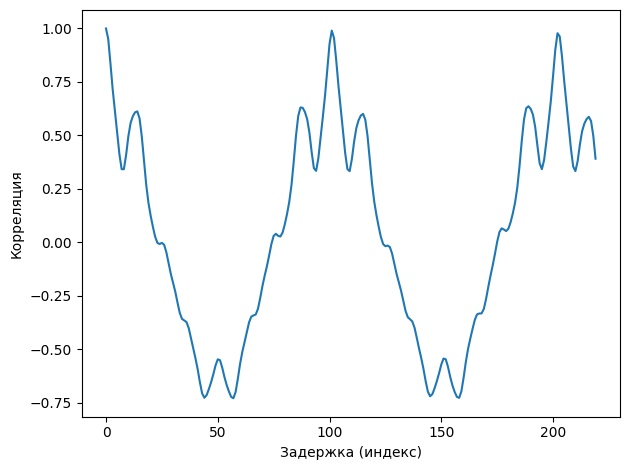

In [6]:
segment = wave.segment(start=0.2, duration=duration)
lags, corrs = autocorr(segment)
plt.plot(lags, corrs)
decorate(xlabel='Задержка (индекс)', ylabel='Корреляция')

## Упражнение 5.2

Инкапсулируем код оценки частоты в функцию `estimate_fundamental` и используем её для отслеживания высоты тона на всей записи.

Затем наложим полученную кривую на спектрограмму.

In [7]:
def estimate_fundamental(segment, low=70, high=150):
    lags, corrs = autocorr(segment)
    lag = np.array(corrs[low:high]).argmax() + low
    period = lag / segment.framerate
    frequency = 1 / period
    return frequency

In [8]:
step = 0.05
starts = np.arange(0.0, 1.4, step)

ts = []
freqs = []

for start in starts:
    ts.append(start + step/2)
    segment = wave.segment(start=start, duration=duration)
    freq = estimate_fundamental(segment)
    freqs.append(freq)

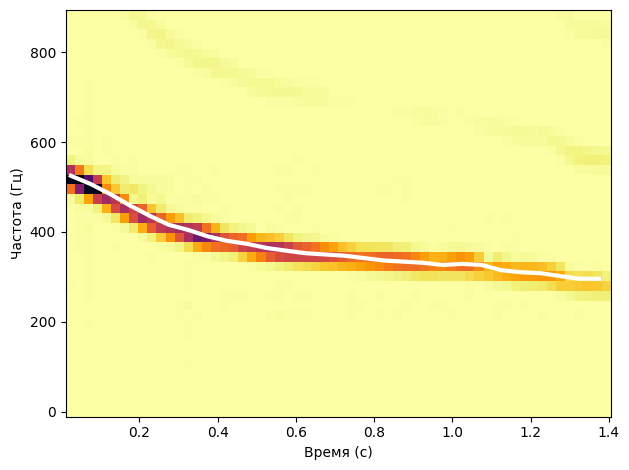

In [9]:
wave.make_spectrogram(2048).plot(high=900)
plt.plot(ts, freqs, color='white', linewidth=3)
decorate(xlabel='Время (с)', 
         ylabel='Частота (Гц)')

Белая кривая показывает отслеженную высоту основного тона. Метод автокорреляции хорошо работает для данного сигнала: кривая плавно следует за изменением частоты чирпа.

## Упражнение 5.3

Используя данные об исторической цене Биткоина (из упражнений предыдущей главы), вычислим автокорреляцию цен.

In [10]:
import pandas as pd

df = pd.read_csv('bitcoin_prices_yfinance.csv', header=[0, 1], index_col=0)
ys = df['Close'].values.flatten()
ts = np.arange(len(ys))

bitcoin_wave = Wave(ys, ts, framerate=1)

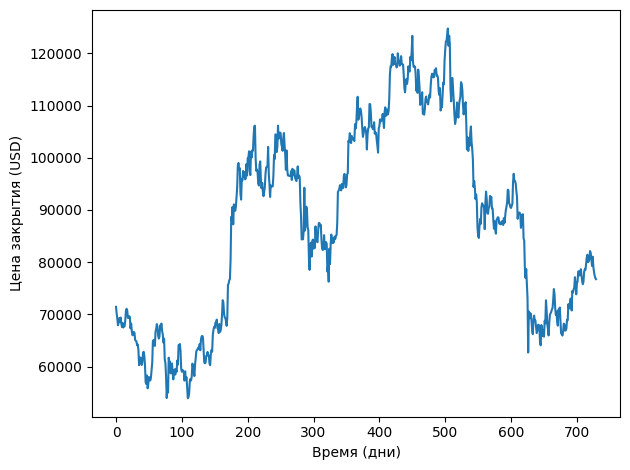

In [11]:
bitcoin_wave.plot()
decorate(xlabel='Время (дни)', ylabel='Цена закрытия (USD)')

Вычислим ACF, используя статистическое определение.

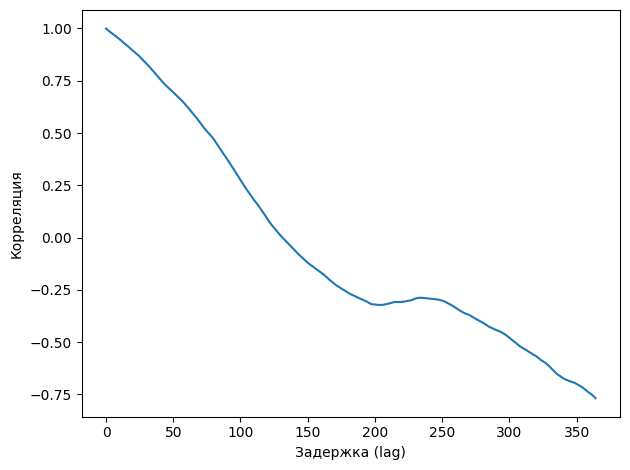

In [12]:
lags, corrs = autocorr(bitcoin_wave)
plt.plot(lags, corrs)
decorate(xlabel='Задержка (lag)', ylabel='Корреляция')

ACF спадает довольно медленно — это указывает на наличие долговременной зависимости (розовый шум, возможно, красный шум). Явных признаков строгой периодичности не наблюдается.

Сравним с реализацией `np.correlate`, которая использует определение корреляции из обработки сигналов (без нормировки и центрирования).

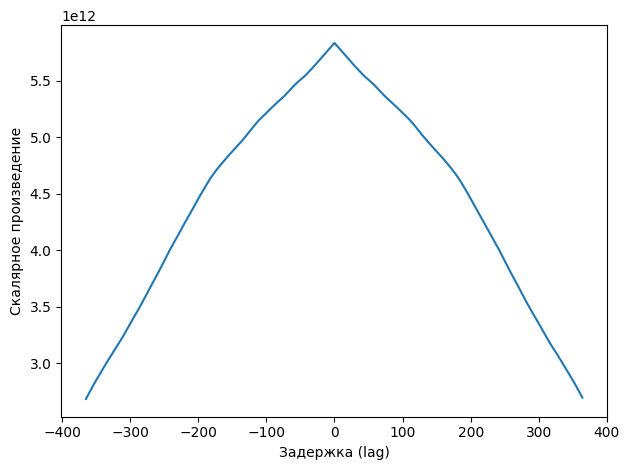

In [13]:
N = len(bitcoin_wave)
corrs2 = np.correlate(bitcoin_wave.ys, bitcoin_wave.ys, mode='same')
lags2 = np.arange(-N//2, N//2)
plt.plot(lags2, corrs2)
decorate(xlabel='Задержка (lag)', ylabel='Скалярное произведение')

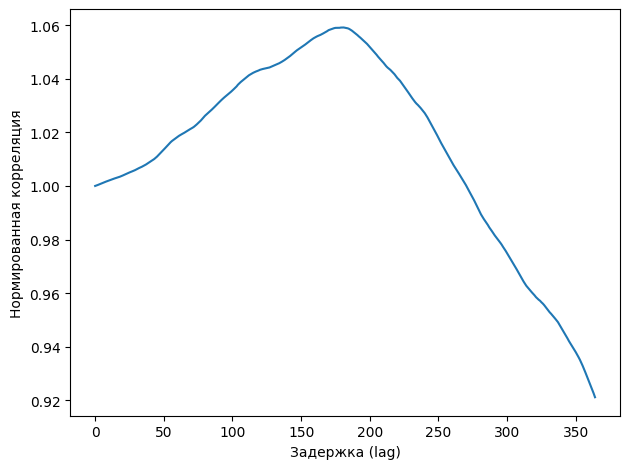

In [14]:
N = len(corrs2)
half = corrs2[N//2:]
lengths = range(N, N//2, -1)
half = half / lengths
half = half / half[0]
plt.plot(half)
decorate(xlabel='Задержка (lag)', ylabel='Нормированная корреляция')

После нормировки результат `np.correlate` качественно похож на ACF, полученную статистическим методом. В обоих случаях корреляция спадает медленно, что характерно для процессов с долговременной памятью.

## Упражнение 5.4

Выберем другой сегмент записи `100475__iluppai__saxophone-weep.wav`. В оригинальной `saxophone.ipynb` используется сегмент, начинающийся в 2.0 с. Выберем другой: например, 1.0 с.

In [15]:
sax_wave = read_wave('../code/100475__iluppai__saxophone-weep.wav')
sax_wave.normalize()
sax_wave.make_audio()

start = 1.0
duration = 0.5
segment = sax_wave.segment(start=start, duration=duration)
segment.make_audio()

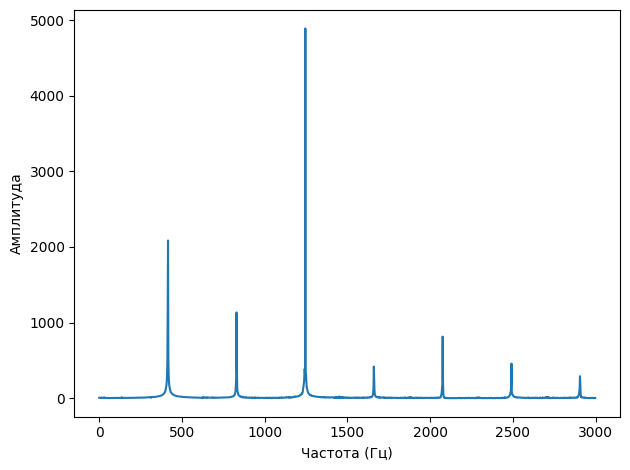

In [16]:
spectrum = segment.make_spectrum()
spectrum.plot(high=3000)
decorate(xlabel='Частота (Гц)', ylabel='Амплитуда')

In [17]:
spectrum.peaks()[:10]

[(np.float64(4889.025369694615), np.float64(1246.0)),
 (np.float64(2085.5024799163334), np.float64(416.0)),
 (np.float64(1152.4385550955153), np.float64(414.0)),
 (np.float64(1134.2367850115916), np.float64(830.0)),
 (np.float64(814.660589992401), np.float64(2076.0)),
 (np.float64(506.8461669013625), np.float64(418.0)),
 (np.float64(470.4485483378759), np.float64(412.0)),
 (np.float64(458.4203162561744), np.float64(2492.0)),
 (np.float64(421.70131635308627), np.float64(832.0)),
 (np.float64(418.8267323220918), np.float64(1660.0))]

Видим пики на частотах, кратных основной. Найдём основную частоту через автокорреляцию.

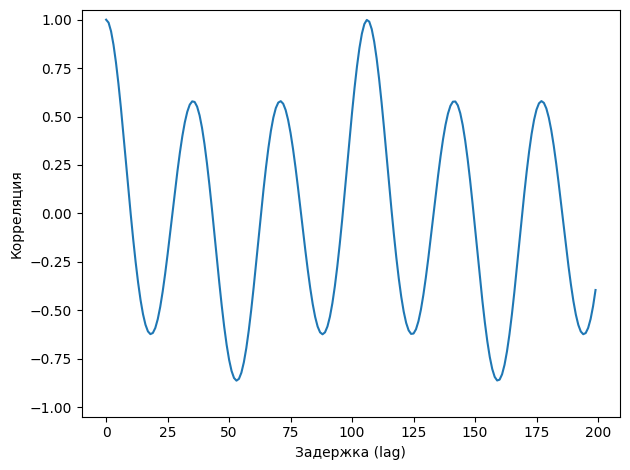

In [18]:
corrs = autocorr_np(segment)
plt.plot(corrs[:200])
decorate(xlabel='Задержка (lag)', ylabel='Корреляция', ylim=[-1.05, 1.05])

In [19]:
def find_frequency(corrs, low, high, framerate):
    lag = np.array(corrs[low:high]).argmax() + low
    period = lag / framerate
    frequency = 1 / period
    return frequency

framerate = segment.framerate
print('Частота по первому пику ACF:', find_frequency(corrs, 80, 100, framerate), 'Гц')

Частота по первому пику ACF: 445.45454545454544 Гц


Проверим феномен пропавшей фундаментальной частоты: удалим нижние частоты высокочастотным фильтром.

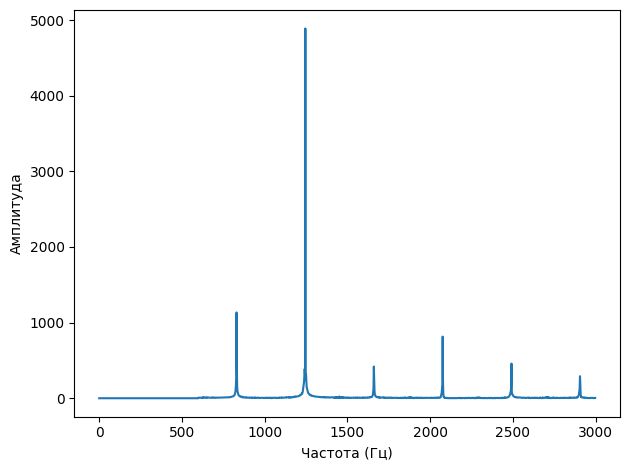

In [20]:
spectrum2 = segment.make_spectrum()
spectrum2.high_pass(600)
spectrum2.plot(high=3000)
decorate(xlabel='Частота (Гц)', ylabel='Амплитуда')

In [21]:
segment2 = spectrum2.make_wave()
segment2.make_audio()

Даже после удаления фундаментальной частоты высота тона воспринимается как та же самая. Проверим это с помощью ACF.

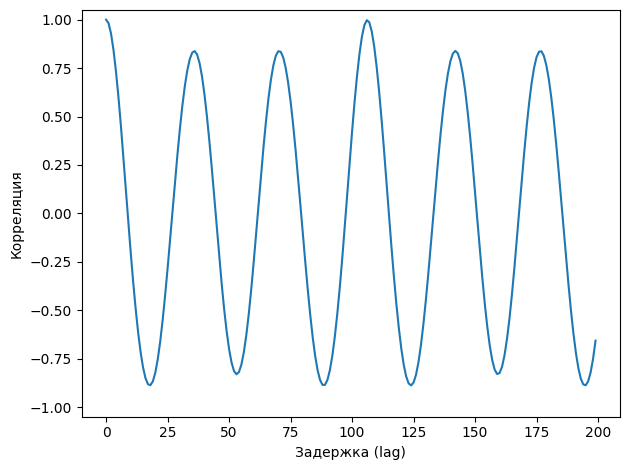

In [22]:
corrs2 = autocorr_np(segment2)
plt.plot(corrs2[:200])
decorate(xlabel='Задержка (lag)', ylabel='Корреляция', ylim=[-1.05, 1.05])

In [23]:
freq_missing = find_frequency(corrs2, 80, 100, framerate)
print('Частота по первому пику ACF после фильтрации:', freq_missing, 'Гц')

Частота по первому пику ACF после фильтрации: 445.45454545454544 Гц


ACF по-прежнему показывает пик на той же частоте, что и исходный сигнал. Это объясняет, почему мы слышим ту же высоту тона: хотя спектральная составляющая на частоте 464 Гц отсутствует, гармоники сохраняют периодичность с тем же периодом.

Таким образом, восприятие высоты тона основано не только на спектральном анализе, но и на механизме, похожем на автокорреляцию.